# 01 — Exploratory Data Analysis: the knockdown dictionary & target states

**Project intention.** Genome-scale CRISPRi Perturb-seq in primary human CD4+ T cells
gives a *measured* causal effect vector for every gene knockdown. We treat those vectors
as a **dictionary** and ask a geometric question: is a target transcriptomic state
(e.g. Th2->Th1 polarization) **reachable** by some non-negative combination of knockdowns?
Because CRISPRi is loss-of-function and the weights are non-negative, the reachable shifts
form a **convex cone**.

This notebook is the *exploratory* groundwork for that method. It characterizes the two
ingredients of the cone problem:

1. **The dictionary `E`** - the perturbation x gene effect matrix (`GWCD4i.DE_stats.h5ad`,
   33,983 x 10,282). Each row is one knockdown's measured effect vector.
2. **The target `d`** - the Th1/Th2 polarization signature (and the aging signature),
   built from published contrasts.

It ends with a **1-D directional preview** of reachability (cosine of each single knockdown
to the target) - a warm-up for the full NNLS convex-cone solver that lives in notebook `03`.

> Guardrails honored here: fixed seed, `fig, ax = plt.subplots()` + `fig.savefig`, knockdown
> effects are loss-of-function, and GATA3 recovery is treated as a **positive control**, not a
> discovery.

In [1]:
import os, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(0)          # fixed seed everywhere
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

DATA = "../data"
H5AD = os.path.join(DATA, "GWCD4i.DE_stats.h5ad")
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)

def csv(name): return pd.read_csv(os.path.join(DATA, name + ".suppl_table.csv"))
print("pandas", pd.__version__, "| numpy", np.__version__)

/Users/justin/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/justin/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


pandas 3.0.3 | numpy 1.26.4


## 1. Data inventory - the two tiers

In [2]:
rows = []
for p in sorted(glob.glob(os.path.join(DATA, "*"))):
    if os.path.isfile(p):
        mb = os.path.getsize(p) / 1e6
        rows.append({"file": os.path.basename(p), "size_MB": round(mb, 2)})
inv = pd.DataFrame(rows)
inv["tier"] = np.where(inv["file"].str.endswith(".h5ad"), "Tier-2 (effect matrix)",
              np.where(inv["file"].str.endswith(".csv"), "Tier-1 (no-auth CSV)", "meta"))
inv.sort_values("size_MB", ascending=False)

,file,size_MB,tier
2,GWCD4i.DE_stats.h5ad,16786.24,Tier-2 (effect matrix)
7,guide_kd_efficiency.suppl_table.csv,13.32,Tier-1 (no-auth CSV)
9,sgrna_library_metadata.suppl_table.csv,9.94,Tier-1 (no-auth CSV)
4,Th2_Th1_polarization_signature_DE_results_full...,6.16,Tier-1 (no-auth CSV)
1,DE_stats.suppl_table.csv,5.34,Tier-1 (no-auth CSV)
0,CD4T_aging_signature_DE_results_full.suppl_tab...,1.99,Tier-1 (no-auth CSV)
5,cluster_autoimmune_enrichment_results.suppl_ta...,0.98,Tier-1 (no-auth CSV)
3,README.md,0.00,meta
6,fetch_de_stats.sh,0.00,meta
8,sample_metadata.suppl_table.csv,0.00,Tier-1 (no-auth CSV)


## 2. Tier-1 - perturbation-level DE summary (`DE_stats`)

One row per **perturbation x culture-condition**: how many genes moved, on-target knockdown
strength/significance, off-target flag, and cross-donor / cross-guide reproducibility. This is
the QC lens on the dictionary - it tells us *which* rows of `E` are trustworthy.

In [3]:
de = csv("DE_stats")
print("shape:", de.shape, "| conditions:", list(de['culture_condition'].unique()))
de[['target_contrast_gene_name','culture_condition','n_total_de_genes',
    'ontarget_effect_size','ontarget_significant','offtarget_flag',
    'crossdonor_correlation_mean','crossguide_correlation']].head()

shape: (33983, 20) | conditions: ['Rest', 'Stim48hr', 'Stim8hr']


,target_contrast_gene_name,culture_condition,n_total_de_genes,ontarget_effect_size,ontarget_significant,offtarget_flag,crossdonor_correlation_mean,crossguide_correlation
0,A1BG,Rest,1,0.0,False,False,NaN,NaN
1,A1BG,Stim48hr,0,0.0,False,False,NaN,NaN
2,A1BG,Stim8hr,1,0.0,False,False,NaN,NaN
3,A2M,Rest,122,0.0,False,False,-0.027619,-0.466086
4,A2M,Stim48hr,45,0.0,False,False,0.061053,0.741714


In [4]:
order = ['Rest','Stim8hr','Stim48hr']
summary = (de.groupby('culture_condition')
             .agg(n_perturbations=('target_contrast_gene_name','size'),
                  frac_ontarget_signif=('ontarget_significant','mean'),
                  median_de_genes=('n_total_de_genes','median'),
                  median_effect=('ontarget_effect_size','median'))
             .reindex(order))
summary.round(3)

,n_perturbations,frac_ontarget_signif,median_de_genes,median_effect
culture_condition,,,,
Rest,11287,0.609,2.0,-5.923
Stim8hr,11415,0.627,2.0,-6.488
Stim48hr,11281,0.638,2.0,-6.529


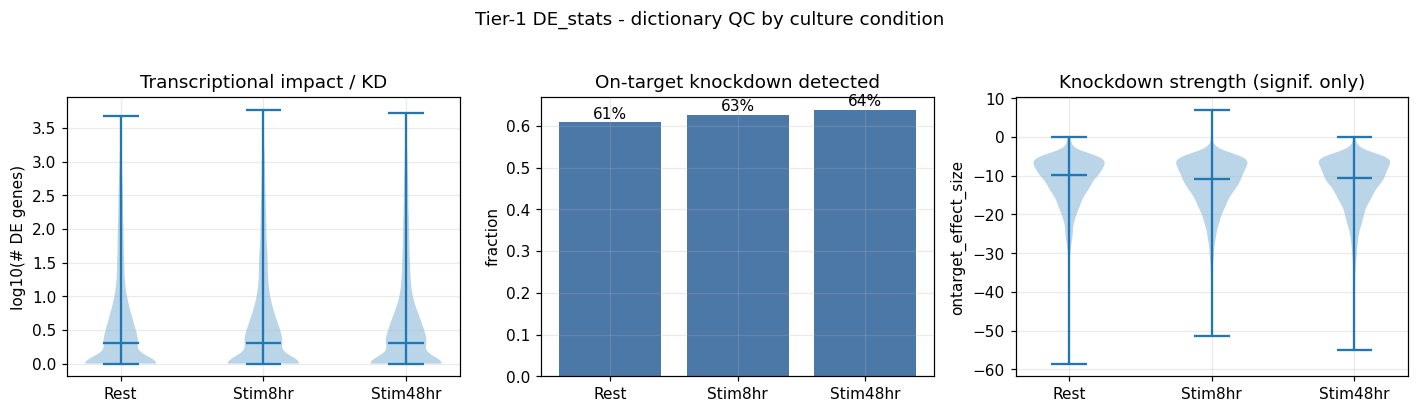

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

data = [np.log10(de.loc[de.culture_condition==c,'n_total_de_genes'].clip(lower=1)) for c in order]
axes[0].violinplot(data, showmedians=True)
axes[0].set_xticks([1,2,3]); axes[0].set_xticklabels(order)
axes[0].set_ylabel("log10(# DE genes)"); axes[0].set_title("Transcriptional impact / KD")

frac = de.groupby('culture_condition')['ontarget_significant'].mean().reindex(order)
axes[1].bar(order, frac.values, color="#4C78A8")
axes[1].set_ylabel("fraction"); axes[1].set_title("On-target knockdown detected")
for i,v in enumerate(frac.values): axes[1].text(i, v+0.01, f"{v:.0%}", ha='center')

sig = de[de.ontarget_significant]
data2 = [sig.loc[sig.culture_condition==c,'ontarget_effect_size'] for c in order]
axes[2].violinplot(data2, showmedians=True)
axes[2].set_xticks([1,2,3]); axes[2].set_xticklabels(order)
axes[2].set_ylabel("ontarget_effect_size"); axes[2].set_title("Knockdown strength (signif. only)")

fig.suptitle("Tier-1 DE_stats - dictionary QC by culture condition", y=1.03)
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_tier1_qc.png"), bbox_inches="tight")
plt.show()

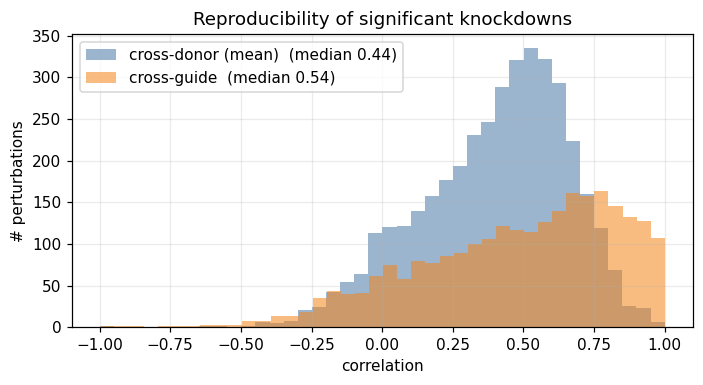

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for col, lab, c in [('crossdonor_correlation_mean','cross-donor (mean)','#4C78A8'),
                    ('crossguide_correlation','cross-guide','#F58518')]:
    v = de.loc[de.ontarget_significant, col].dropna()
    ax.hist(v, bins=40, alpha=0.55, label=f"{lab}  (median {v.median():.2f})", color=c)
ax.set_xlabel("correlation"); ax.set_ylabel("# perturbations")
ax.set_title("Reproducibility of significant knockdowns"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_reproducibility.png"), bbox_inches="tight")
plt.show()

## 3. The knockdown dictionary `E` (Tier-2 `GWCD4i.DE_stats.h5ad`)

The effect matrix itself. `X` is empty - the effects live in **named layers**
(`zscore`, `log_fc`, `p_value`, ...). We read structure and a `zscore` sample with `h5py`
(no `anndata` needed) to keep memory modest; the full float64 `zscore` layer is ~2.8 GB.

In [7]:
def read_obs(h, name):
    """Read an obs column, decoding AnnData categoricals to a numpy array of strings."""
    node = h['obs'][name]
    if isinstance(node, h5py.Group):                      # categorical
        cats = node['categories'][:]
        cats = np.array([c.decode() if isinstance(c, bytes) else c for c in cats])
        codes = node['codes'][:]
        return np.where(codes >= 0, cats[codes.clip(min=0)], None)
    v = node[:]
    if v.dtype.kind == 'S': v = np.array([x.decode() for x in v])
    return v

with h5py.File(H5AD, "r") as h:
    n_obs, n_var = h['layers/zscore'].shape
    layers = list(h['layers'].keys())
    var_gene = np.array([x.decode() for x in h['var']['gene_name'][:]])
    obs_gene = read_obs(h, 'target_contrast_gene_name')
    obs_cond = read_obs(h, 'culture_condition')
    obs_sig  = h['obs']['ontarget_significant'][:]
    obs_eff  = h['obs']['ontarget_effect_size'][:]

print(f"E shape (perturbation x gene): {n_obs:,} x {n_var:,}")
print("layers:", layers)
print("unique target genes:", pd.Series(obs_gene).nunique(), "| conditions:", sorted(set(obs_cond)))
print("on-target-significant rows:", int(obs_sig.sum()), f"({obs_sig.mean():.1%})")

E shape (perturbation x gene): 33,983 x 10,282
layers: ['adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore']
unique target genes: 11526 | conditions: ['Rest', 'Stim48hr', 'Stim8hr']
on-target-significant rows: 21221 (62.4%)


In [8]:
tbl = (pd.DataFrame({'condition': obs_cond, 'signif': obs_sig})
         .groupby('condition')['signif'].agg(['size','sum','mean'])
         .rename(columns={'size':'n_rows','sum':'n_signif','mean':'frac_signif'})
         .reindex(['Rest','Stim8hr','Stim48hr']))
tbl['n_signif'] = tbl['n_signif'].astype(int)
tbl.round(3)

,n_rows,n_signif,frac_signif
condition,,,
Rest,11287,6871,0.609
Stim8hr,11415,7155,0.627
Stim48hr,11281,7195,0.638


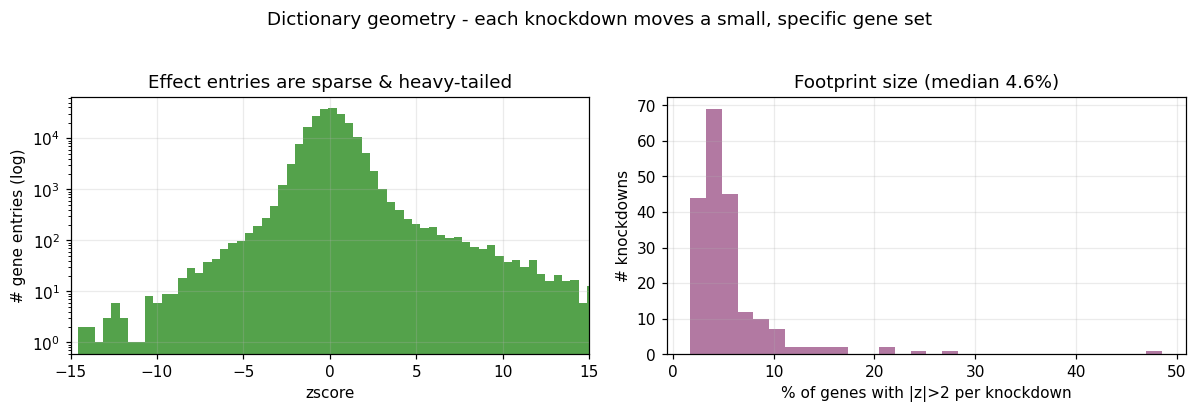

In [9]:
# Distribution of zscore effects for a random sample of significant knockdowns.
sig_idx = np.where(obs_sig)[0]
sample_rows = np.sort(RNG.choice(sig_idx, size=200, replace=False))
with h5py.File(H5AD, "r") as h:
    Zsamp = h['layers/zscore'][sample_rows, :]      # 200 x 10,282
Zsamp = np.nan_to_num(Zsamp)

frac_moved = (np.abs(Zsamp) > 2).mean(axis=1)       # |z|>2 ~ nominal per-gene significance
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(Zsamp[RNG.integers(0,200,20)].ravel(), bins=80, color="#54A24B")
axes[0].set_xlim(-15,15); axes[0].set_yscale('log')
axes[0].set_xlabel("zscore"); axes[0].set_ylabel("# gene entries (log)")
axes[0].set_title("Effect entries are sparse & heavy-tailed")
axes[1].hist(100*frac_moved, bins=30, color="#B279A2")
axes[1].set_xlabel("% of genes with |z|>2 per knockdown"); axes[1].set_ylabel("# knockdowns")
axes[1].set_title(f"Footprint size (median {100*np.median(frac_moved):.1f}%)")
fig.suptitle("Dictionary geometry - each knockdown moves a small, specific gene set", y=1.03)
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_dictionary_geometry.png"), bbox_inches="tight")
plt.show()

## 4. Target states - Th1/Th2 polarization (and aging)

The polarization signature comes from **two** independent Th2-vs-Th1 contrasts
(Ota 2021, Hollbacher 2021). We (a) check the biological **sign convention** for
`toward_Th1`, and (b) measure **cross-source concordance** - the target vector is built
only from the sign-concordant core, which is what makes it trustworthy.

In [10]:
pol = csv("Th2_Th1_polarization_signature_DE_results_full")
print("contrasts:", list(pol['contrast'].unique()))

# toward_Th1 = flip the sign of Th2_vs_Th1 (positive logFC = higher in Th2).
# Expected for toward_Th1: GATA3/IL4/IL5/IL13 DOWN, TBX21/IFNG/STAT1/STAT4 UP.
markers = ['GATA3','IL4','IL5','IL13','TBX21','IFNG','STAT1','STAT4']
piv = pol.pivot_table(index='variable', columns='contrast', values='zscore', aggfunc='mean')
mk = piv.loc[piv.index.intersection(markers)] * -1.0   # sign flip -> toward_Th1
mk.columns = [c.split('(')[-1].rstrip(')') for c in mk.columns]
print("\ntoward_Th1 z-scores (neg = expected DOWN for Th2 genes, pos = UP for Th1 genes):")
mk.round(2)

contrasts: ['Th2_vs_Th1 (Ota 2021)', 'Th2_vs_Th1 (Hollbacker 2021)']

toward_Th1 z-scores (neg = expected DOWN for Th2 genes, pos = UP for Th1 genes):


,Hollbacker 2021,Ota 2021
variable,,
GATA3,-5.83,-24.64
IFNG,5.11,25.73
IL13,-3.01,-11.88
IL4,NaN,-5.77
IL5,NaN,-4.91
STAT1,2.41,7.47
STAT4,2.65,20.47
TBX21,11.44,33.62


shared genes: 11,616 | sign-concordant: 68.5% | Spearman rho = 0.562


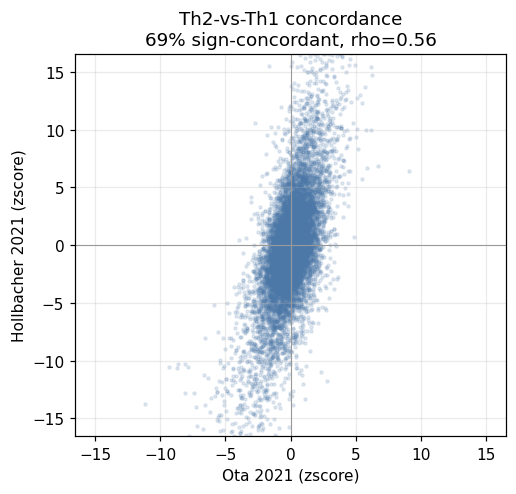

In [11]:
p = piv.dropna()
p.columns = ['ota','holl']
shared = p.shape[0]
sign_conc = float(np.mean(np.sign(p['ota']) == np.sign(p['holl'])))
rho = spearmanr(p['ota'], p['holl']).correlation
print(f"shared genes: {shared:,} | sign-concordant: {sign_conc:.1%} | Spearman rho = {rho:.3f}")

fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.scatter(p['ota'], p['holl'], s=4, alpha=0.15, color="#4C78A8")
lim = np.percentile(np.abs(p.values), 99)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.axhline(0, color='#999', lw=.7); ax.axvline(0, color='#999', lw=.7)
for g in ['GATA3','TBX21','IFNG','IL4']:
    if g in p.index: ax.annotate(g, (p.loc[g,'ota'], p.loc[g,'holl']), fontsize=8, color='darkred')
ax.set_xlabel("Ota 2021 (zscore)"); ax.set_ylabel("Hollbacher 2021 (zscore)")
ax.set_title(f"Th2-vs-Th1 concordance\n{sign_conc:.0%} sign-concordant, rho={rho:.2f}")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_target_concordance.png"), bbox_inches="tight")
plt.show()

## 5. Reachability preview - and why knockdown-only changes the geometry

A cheap warm-up for the convex-cone solver: for each **single** knockdown (a row of `E`),
score how well its effect vector aligns with the target direction `d`, over the genes they
share. But there is a subtlety that is the whole point of the project:

The `toward_Th1` target is **bidirectional** - some genes should go **down** (Th2 program:
GATA3, IL4...) and some should go **up** (Th1 program: TBX21, IFNG...). CRISPRi is
**loss-of-function**: a knockdown can push genes *down*, but it cannot *activate* the Th1
half. So a naive cosine against the full bidirectional target **penalizes** even the
canonical answer. We show this explicitly by scoring GATA3 (the master Th2 regulator) two
ways:

- **full target** (both halves) - GATA3 is diluted by the "should-go-up" genes it cannot move;
- **down-only** target (the half a knockdown *can* reach) - GATA3 rises sharply.

That gap is exactly why the headline method uses **non-negative combinations restricted to
the achievable directions** (the cone), not a single-vector cosine.

In [12]:
# Build target d over gene symbols; keep only the sign-concordant core.
core = p[np.sign(p['ota']) == np.sign(p['holl'])]
tgt = (-1.0 * core.mean(axis=1))                     # toward_Th1 (sign-flipped Th2_vs_Th1)
print(f"target vector d: {tgt.shape[0]:,} genes (sign-concordant core)")

gene_pos = {g:i for i,g in enumerate(var_gene)}
present = [g for g in tgt.index if g in gene_pos]
col_idx = np.array([gene_pos[g] for g in present])
d_full = tgt[present].values
print(f"shared target genes present in E: {len(present):,}  "
      f"({(d_full<0).sum():,} down / {(d_full>0).sum():,} up)")

rows_rest = np.sort(np.where((obs_cond == 'Rest') & obs_sig)[0])
with h5py.File(H5AD, "r") as h:
    Esub = h['layers/zscore'][rows_rest, :][:, col_idx]      # (n_rest_signif, n_shared)
Esub = np.nan_to_num(Esub)
genes_rest = obs_gene[rows_rest]
print("E subblock:", Esub.shape)

target vector d: 7,960 genes (sign-concordant core)
shared target genes present in E: 6,188  (2,985 down / 3,203 up)


E subblock: (6871, 6188)


In [13]:
def cos_to(target_vec):
    t = target_vec / (np.linalg.norm(target_vec) + 1e-12)
    return (Esub @ t) / (np.linalg.norm(Esub, axis=1) + 1e-12)

d_down = np.where(d_full < 0, d_full, 0.0)            # only the half CRISPRi can reach
cos_full = cos_to(d_full)
cos_down = cos_to(d_down)

def rank_of(score, name='GATA3'):
    ranked = genes_rest[np.argsort(-score)]
    hit = np.where(ranked == name)[0]
    return (int(hit[0]) + 1) if len(hit) else None

n = len(genes_rest)
r_full, r_down = rank_of(cos_full), rank_of(cos_down)
print(f"GATA3 among {n:,} significant Rest knockdowns:")
print(f"   full bidirectional target : #{r_full}  (top {100*r_full/n:.1f}%)")
print(f"   down-only  (achievable)   : #{r_down}  (top {100*r_down/n:.1f}%)")

GATA3 among 6,871 significant Rest knockdowns:
   full bidirectional target : #155  (top 2.3%)
   down-only  (achievable)   : #11  (top 0.2%)


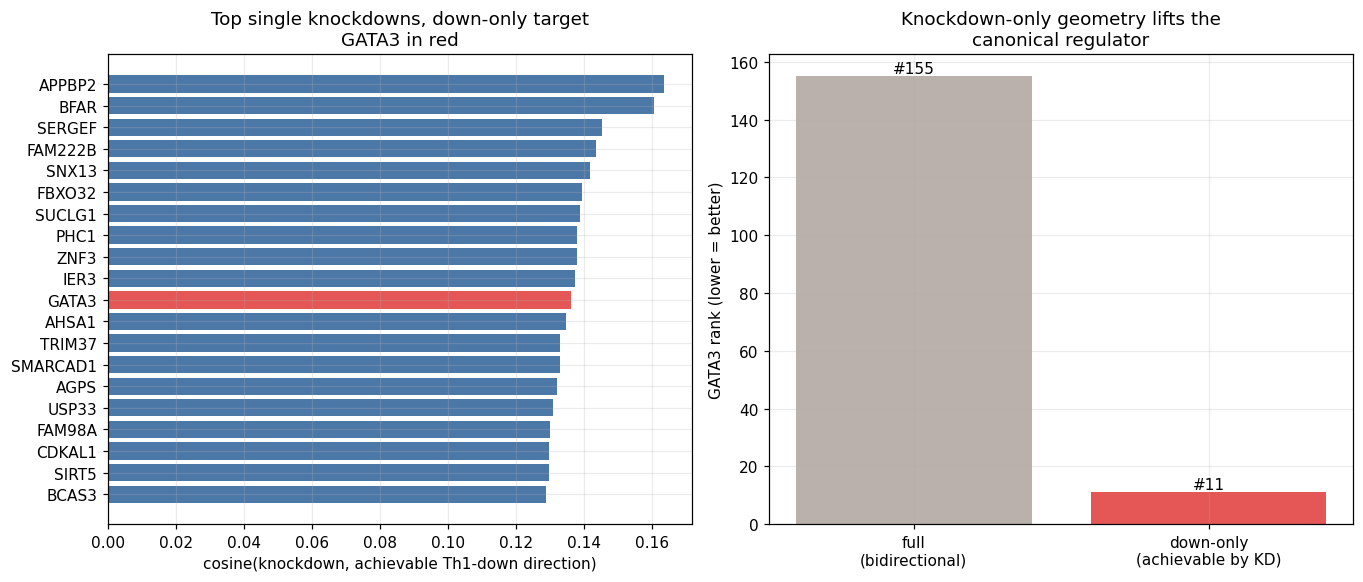

,gene,cos_full,cos_down
0,APPBP2,0.182569,0.163395
1,BFAR,0.096958,0.160548
2,SERGEF,0.044626,0.145259
3,FAM222B,0.009692,0.143572
4,SNX13,0.009129,0.141644
5,FBXO32,0.176135,0.139361
6,SUCLG1,0.040493,0.138790
7,PHC1,-0.012141,0.137984
8,ZNF3,0.014087,0.137852
9,IER3,0.018370,0.137296


In [14]:
res = (pd.DataFrame({'gene': genes_rest, 'cos_full': cos_full, 'cos_down': cos_down})
         .sort_values('cos_down', ascending=False).reset_index(drop=True))
top = res.head(20)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
# left: top-20 by the achievable (down-only) alignment
colors = ['#E45756' if g == 'GATA3' else '#4C78A8' for g in top['gene']]
axes[0].barh(top['gene'][::-1], top['cos_down'][::-1], color=colors[::-1])
axes[0].set_xlabel("cosine(knockdown, achievable Th1-down direction)")
axes[0].set_title("Top single knockdowns, down-only target\nGATA3 in red")
# right: GATA3 percentile shifts when we restrict to the achievable half
labels = ['full\n(bidirectional)', 'down-only\n(achievable by KD)']
ranks = [r_full, r_down]
axes[1].bar(labels, ranks, color=['#BAB0AC', '#E45756'])
for i, v in enumerate(ranks): axes[1].text(i, v, f"#{v}", ha='center', va='bottom')
axes[1].set_ylabel("GATA3 rank (lower = better)")
axes[1].set_title("Knockdown-only geometry lifts the\ncanonical regulator")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_reachability_preview.png"), bbox_inches="tight")
plt.show()
res.head(10)

## 6. Disease linkage - autoimmune enrichment

The `cluster_autoimmune_enrichment` table connects perturbation clusters to autoimmune-disease
GWAS gene sets - the layer that turns a nomination into a potential *impact* claim.

enrichments FDR<0.05: 185 across 16 diseases


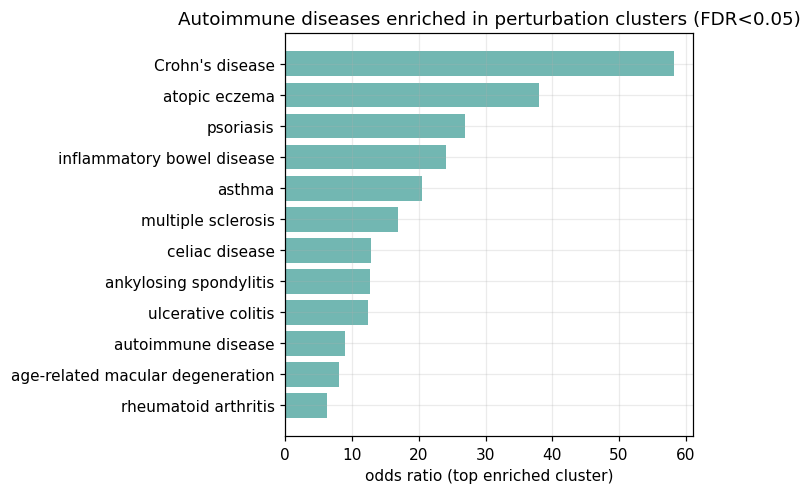

,disease,gene_set,odds_ratio,p_adj_fdr,cluster_size
0,Crohn's disease,regulators,58.173,0.000,6
1,atopic eczema,regulators,38.063,0.003,6
2,psoriasis,regulators,26.898,0.004,6
3,inflammatory bowel disease,regulators,24.006,0.003,6
4,asthma,downstream_Stim8hr,20.424,0.000,12
5,multiple sclerosis,regulators,16.893,0.035,6
6,celiac disease,downstream_Stim8hr,12.826,0.025,12
7,ankylosing spondylitis,downstream_Stim8hr,12.745,0.003,12
8,ulcerative colitis,downstream_Stim8hr,12.329,0.003,12
9,autoimmune disease,regulators,8.955,0.035,6


In [15]:
enr = csv("cluster_autoimmune_enrichment_results")
sig_enr = enr[enr['p_adj_fdr'] < 0.05].copy()
print(f"enrichments FDR<0.05: {len(sig_enr):,} across {sig_enr['disease'].nunique()} diseases")

top_dz = (sig_enr.sort_values('odds_ratio', ascending=False)
                 .drop_duplicates('disease').head(12))
fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.barh(top_dz['disease'][::-1], top_dz['odds_ratio'][::-1], color="#72B7B2")
ax.set_xlabel("odds ratio (top enriched cluster)")
ax.set_title("Autoimmune diseases enriched in perturbation clusters (FDR<0.05)")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,"01_autoimmune.png"), bbox_inches="tight")
plt.show()
top_dz[['disease','gene_set','odds_ratio','p_adj_fdr','cluster_size']].round(3).reset_index(drop=True)

## 7. Takeaways -> the reachability method

- **The dictionary is well-behaved.** On-target knockdown is detected in a large fraction of
  perturbations, effects are reproducible across donors and guides, and each knockdown moves a
  small, specific gene set - the rows of `E` are sparse, heavy-tailed vectors (a good basis for
  a cone).
- **The target is trustworthy.** Two independent Th2-vs-Th1 contrasts agree in sign on the core,
  so `d` is built from the concordant subset, not one noisy study.
- **The knockdown-only constraint is real and visible.** Against the *full* bidirectional
  target, even GATA3 - the textbook Th2 master regulator - lands only in the top ~2% by a
  naive single-vector cosine, because CRISPRi cannot activate the Th1 half of the signature.
  Restricting to the **achievable (down) directions** lifts GATA3 into the top handful. This
  is not a plumbing bug; it is the core modeling insight that *motivates* the cone method.

**What this notebook is *not*:** it is not the reachability verdict. A single-vector cosine
ranks *individual* knockdowns and is deliberately crude; the headline method asks whether a
**non-negative combination** of knockdowns reaches `d` (the convex cone), returns a falsifiable
`reachable / outside` verdict with a residual, and calibrates it against a shuffled-target
null. That lives in `03_counterfactual.ipynb` on top of the `src/reachability.py` solver.

> Reminder: every nomination here is a **hypothesis for wet-lab test**, multi-gene sets assume
> additivity (no epistasis), and recovering known regulators is **validation**, not discovery.